In [23]:
# ── CÉLULA 0: mount Google Drive ────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os

# Caminho base do projeto — tudo será salvo aqui
BASE = '/content/drive/MyDrive/Inferência Bayesiana Aplicada'

# Estrutura de diretórios
dirs = ['notebooks', 'src', 'data/raw', 'data/clean', 'reports']
for d in dirs:
    os.makedirs(f'{BASE}/{d}', exist_ok=True)

print(f"✓ Drive montado")
print(f"✓ Projeto em: {BASE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Drive montado
✓ Projeto em: /content/drive/MyDrive/Inferência Bayesiana Aplicada


In [24]:
# ── CÉLULA 1: instalação ────────────────────────────────────────────────────
!pip install pymc>=5.0 arviz>=0.16 --quiet

In [26]:
# ── CÉLULA 2: imports ───────────────────────────────────────────────────────
import pymc as pm
import arviz as az
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

BASE = '/content/drive/MyDrive/Inferência Bayesiana Aplicada'
print(f"PyMC  : {pm.__version__}")
print(f"ArviZ : {az.__version__}")
print(f"NumPy : {np.__version__}")
print("✓ Todos os imports OK")

PyMC  : 5.28.5
ArviZ : 0.22.0
NumPy : 2.0.2
✓ Todos os imports OK


In [27]:
# ── CÉLULA 3 — ajuste de draws ──────────────────────────────────────────────
with pm.Model() as test_model:
    theta = pm.Beta('theta', alpha=1, beta=1)
    obs   = pm.Binomial('obs', n=100, p=theta, observed=55)
    trace = pm.sample(draws=1000, chains=2, progressbar=True)

rhat = float(az.rhat(trace)['theta'])
ess  = float(az.ess(trace)['theta'])

print(f"R-hat : {rhat:.4f}  {'✓ OK' if rhat < 1.01 else '✗ PROBLEMA'}")
print(f"ESS   : {ess:.0f}   {'✓ OK' if ess > 400 else '✗ PROBLEMA'}")

Output()

R-hat : 0.9999  ✓ OK
ESS   : 858   ✓ OK


## 1. Teorema de Bayes

$$P(\theta \mid data) \propto P(data \mid \theta) \times P(\theta)$$

| Componente | Notação | Significado |
|---|---|---|
| **Prior** | $P(\theta)$ | O que acredito **antes** de ver os dados |
| **Likelihood** | $P(data \mid \theta)$ | Probabilidade dos dados dado $\theta$ |
| **Posterior** | $P(\theta \mid data)$ | O que acredito **depois** de ver os dados |

### Intuição de negócio

> Se o histórico diz que a taxa de conversão é ~5% (prior)  
> e os dados novos mostram 12% (likelihood),  
> o posterior ficará **entre os dois**, ponderado pelo volume de dados.  
> Quanto mais dados, menos o prior importa.

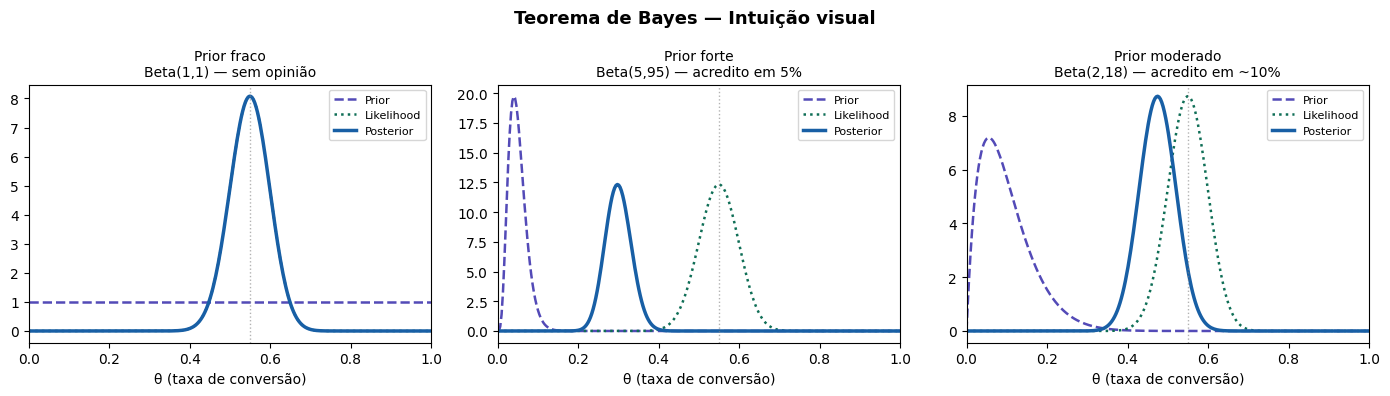

✓ Gráfico salvo em reports/


In [28]:
# ── CÉLULA 5: demonstração visual do Prior → Posterior ──────────────────────
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Teorema de Bayes — Intuição visual', fontsize=13, fontweight='bold')

theta = np.linspace(0, 1, 300)

# Cenário: 55 conversões em 100 visitas
n, k = 100, 55

priors = [
    (1,  1,  "Prior fraco\nBeta(1,1) — sem opinião"),
    (5,  95, "Prior forte\nBeta(5,95) — acredito em 5%"),
    (2,  18, "Prior moderado\nBeta(2,18) — acredito em ~10%"),
]

for ax, (a, b, label) in zip(axes, priors):
    prior     = stats.beta.pdf(theta, a, b)
    posterior = stats.beta.pdf(theta, a + k, b + n - k)
    likelihood = stats.binom.pmf(k, n, theta)
    likelihood = likelihood / likelihood.max() * posterior.max()  # escala visual

    ax.plot(theta, prior,      '--', color='#534AB7', lw=1.8, label='Prior')
    ax.plot(theta, likelihood,  ':',  color='#0F6E56', lw=1.8, label='Likelihood')
    ax.plot(theta, posterior,        color='#185FA5', lw=2.5, label='Posterior')
    ax.axvline(k/n, color='gray', lw=1, linestyle=':', alpha=0.6)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('θ (taxa de conversão)')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(f'{BASE}/reports/teorema_bayes_visual.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico salvo em reports/")

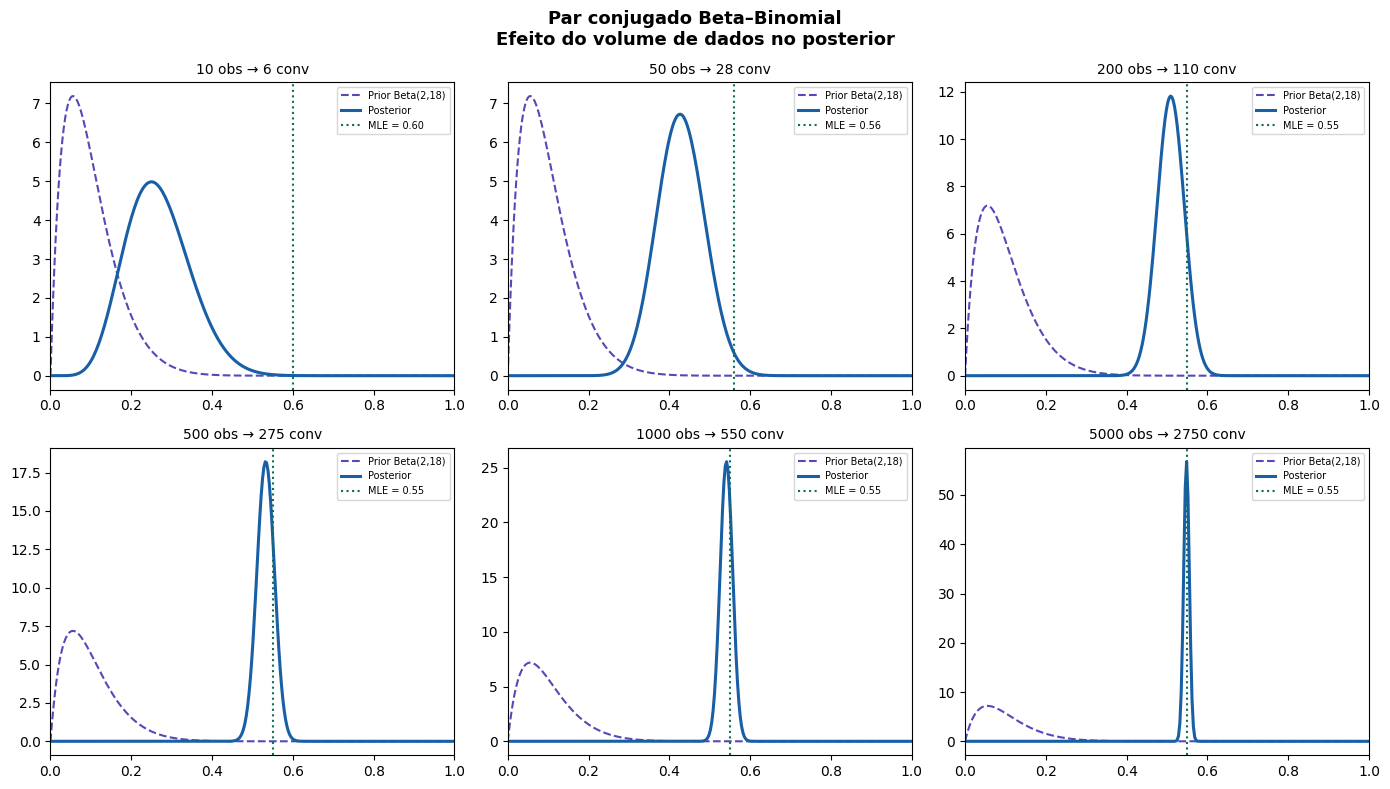

✓ Gráfico salvo em reports/


In [29]:
# ── CÉLULA 6: distribuições conjugadas — Beta-Binomial ──────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Par conjugado Beta–Binomial\nEfeito do volume de dados no posterior',
             fontsize=13, fontweight='bold')

# Prior fixo: Beta(2, 18) — crença inicial de ~10% de conversão
a0, b0 = 2, 18

# Diferentes volumes de dados observados (todos com ~55% de conversão)
experimentos = [
    (10,  6,  "10 obs → 6 conv"),
    (50,  28, "50 obs → 28 conv"),
    (200, 110,"200 obs → 110 conv"),
    (500, 275,"500 obs → 275 conv"),
    (1000,550,"1000 obs → 550 conv"),
    (5000,2750,"5000 obs → 2750 conv"),
]

for ax, (n, k, label) in zip(axes.flat, experimentos):
    prior     = stats.beta.pdf(theta, a0, b0)
    posterior = stats.beta.pdf(theta, a0 + k, b0 + n - k)

    ax.plot(theta, prior,     '--', color='#534AB7', lw=1.5, label=f'Prior Beta({a0},{b0})')
    ax.plot(theta, posterior,       color='#185FA5', lw=2.2, label='Posterior')
    ax.axvline(k/n,  color='#0F6E56', lw=1.5, linestyle=':', label=f'MLE = {k/n:.2f}')
    ax.set_title(label, fontsize=10)
    ax.set_xlim(0, 1)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(f'{BASE}/reports/conjugate_beta_binomial.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico salvo em reports/")

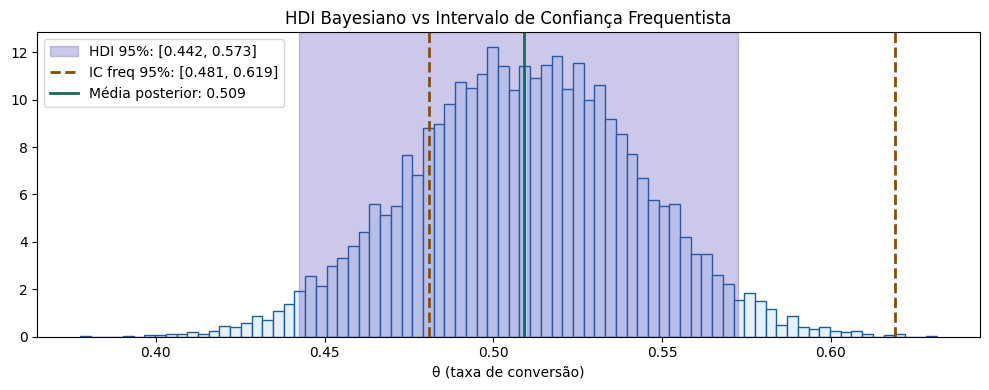

HDI 95%  : [0.4424, 0.5725]
IC freq  : [0.4811, 0.6189]

Diferença chave:
  HDI: 'há 95% de probabilidade de θ estar neste intervalo'
  IC : 'se repetirmos o experimento infinitas vezes, 95% dos ICs conterão o verdadeiro θ'


In [30]:
# ── CÉLULA 7: HDI vs Intervalo de Confiança frequentista ────────────────────
# Posterior de um experimento: 110 conversões em 200 visitas
a_post, b_post = 2 + 110, 18 + 90
amostras = stats.beta.rvs(a_post, b_post, size=10000, random_state=42)

# HDI 95% (Highest Density Interval)
hdi = az.hdi(amostras, hdi_prob=0.95)

# IC frequentista 95%
p_hat = 110 / 200
ic_low  = p_hat - 1.96 * np.sqrt(p_hat * (1 - p_hat) / 200)
ic_high = p_hat + 1.96 * np.sqrt(p_hat * (1 - p_hat) / 200)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(amostras, bins=80, density=True, color='#E6F1FB', edgecolor='#185FA5', lw=0.5)
ax.axvspan(hdi[0], hdi[1], alpha=0.3, color='#534AB7', label=f'HDI 95%: [{hdi[0]:.3f}, {hdi[1]:.3f}]')
ax.axvline(ic_low,  color='#854F0B', lw=2, linestyle='--', label=f'IC freq 95%: [{ic_low:.3f}, {ic_high:.3f}]')
ax.axvline(ic_high, color='#854F0B', lw=2, linestyle='--')
ax.axvline(amostras.mean(), color='#0F6E56', lw=2, label=f'Média posterior: {amostras.mean():.3f}')
ax.set_xlabel('θ (taxa de conversão)')
ax.set_title('HDI Bayesiano vs Intervalo de Confiança Frequentista', fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig(f'{BASE}/reports/hdi_vs_ic.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"HDI 95%  : [{hdi[0]:.4f}, {hdi[1]:.4f}]")
print(f"IC freq  : [{ic_low:.4f}, {ic_high:.4f}]")
print(f"\nDiferença chave:")
print(f"  HDI: 'há 95% de probabilidade de θ estar neste intervalo'")
print(f"  IC : 'se repetirmos o experimento infinitas vezes, 95% dos ICs conterão o verdadeiro θ'")

In [31]:
# ── CÉLULA 8: salvar notebook no Drive ──────────────────────────────────────
import shutil, glob

# Copia todos os .ipynb abertos para a pasta notebooks/ do projeto
for nb in glob.glob('/content/*.ipynb'):
    shutil.copy(nb, f'{BASE}/notebooks/')

print("✓ Notebook salvo em:", f'{BASE}/notebooks/')

✓ Notebook salvo em: /content/drive/MyDrive/Inferência Bayesiana Aplicada/notebooks/


In [33]:
# ── CÉLULA 9: download do dataset (fallback Kaggle) ─────────────────────────
!pip install kagglehub --quiet

import kagglehub
import pandas as pd
import shutil, os

# Download do dataset
path = kagglehub.dataset_download("faviovaz/marketing-ab-testing")
print(f"Arquivos baixados em: {path}")
print(os.listdir(path))

100%|██████████| 5.23M/5.23M [00:00<00:00, 72.6MB/s]

Extracting files...


Arquivos baixados em: /root/.cache/kagglehub/datasets/faviovaz/marketing-ab-testing/versions/1
['marketing_AB.csv']


In [34]:
# ── CÉLULA 10: carregar e inspecionar ───────────────────────────────────────
# Ajuste o nome do arquivo conforme o output da célula anterior
csv_path = os.path.join(path, os.listdir(path)[0])
df_raw = pd.read_csv(csv_path)

# Salvar raw no Drive
df_raw.to_csv(f'{BASE}/data/raw/marketing_AB_raw.csv', index=False)

print(f"Shape: {df_raw.shape}")
print(f"\nColunas: {list(df_raw.columns)}")
print(f"\nTipos:\n{df_raw.dtypes}")
print(f"\nNulos:\n{df_raw.isnull().sum()}")
df_raw.head()

Shape: (588101, 7)

Colunas: ['Unnamed: 0', 'user id', 'test group', 'converted', 'total ads', 'most ads day', 'most ads hour']

Tipos:
Unnamed: 0        int64
user id           int64
test group       object
converted          bool
total ads         int64
most ads day     object
most ads hour     int64
dtype: object

Nulos:
Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [35]:
# ── CÉLULA 11: limpeza e validação ──────────────────────────────────────────
df = df_raw.copy()

# Renomear colunas para snake_case
df.columns = ['index', 'user_id', 'test_group', 'converted', 'total_ads', 'most_ads_day', 'most_ads_hour']
df = df.drop(columns=['index'])

# Validações
assert df['converted'].isin([0, 1]).all(),         "❌ converted não é binária"
assert df['test_group'].isin(['ad', 'psa']).all(),  "❌ grupos inesperados"
assert df['user_id'].nunique() == len(df),          "❌ user_id com duplicatas"
assert df.isnull().sum().sum() == 0,                "❌ há valores nulos"

# Variável derivada: grupo como binário (1 = tratamento/ad)
df['group_binary'] = (df['test_group'] == 'ad').astype(int)

# Estatísticas por grupo
summary = df.groupby('test_group')['converted'].agg(['count','sum','mean'])
summary.columns = ['n_total', 'n_convertidos', 'taxa_conversao']

print("✓ Todas as validações passaram\n")
print(summary.round(4))

# Salvar
df.to_parquet(f'{BASE}/data/clean/ab_test_clean.parquet', index=False)
print(f"\n✓ Dataset limpo salvo em data/clean/")
print(f"  Shape final: {df.shape}")

✓ Todas as validações passaram

            n_total  n_convertidos  taxa_conversao
test_group                                        
ad           564577          14423          0.0255
psa           23524            420          0.0179

✓ Dataset limpo salvo em data/clean/
  Shape final: (588101, 7)


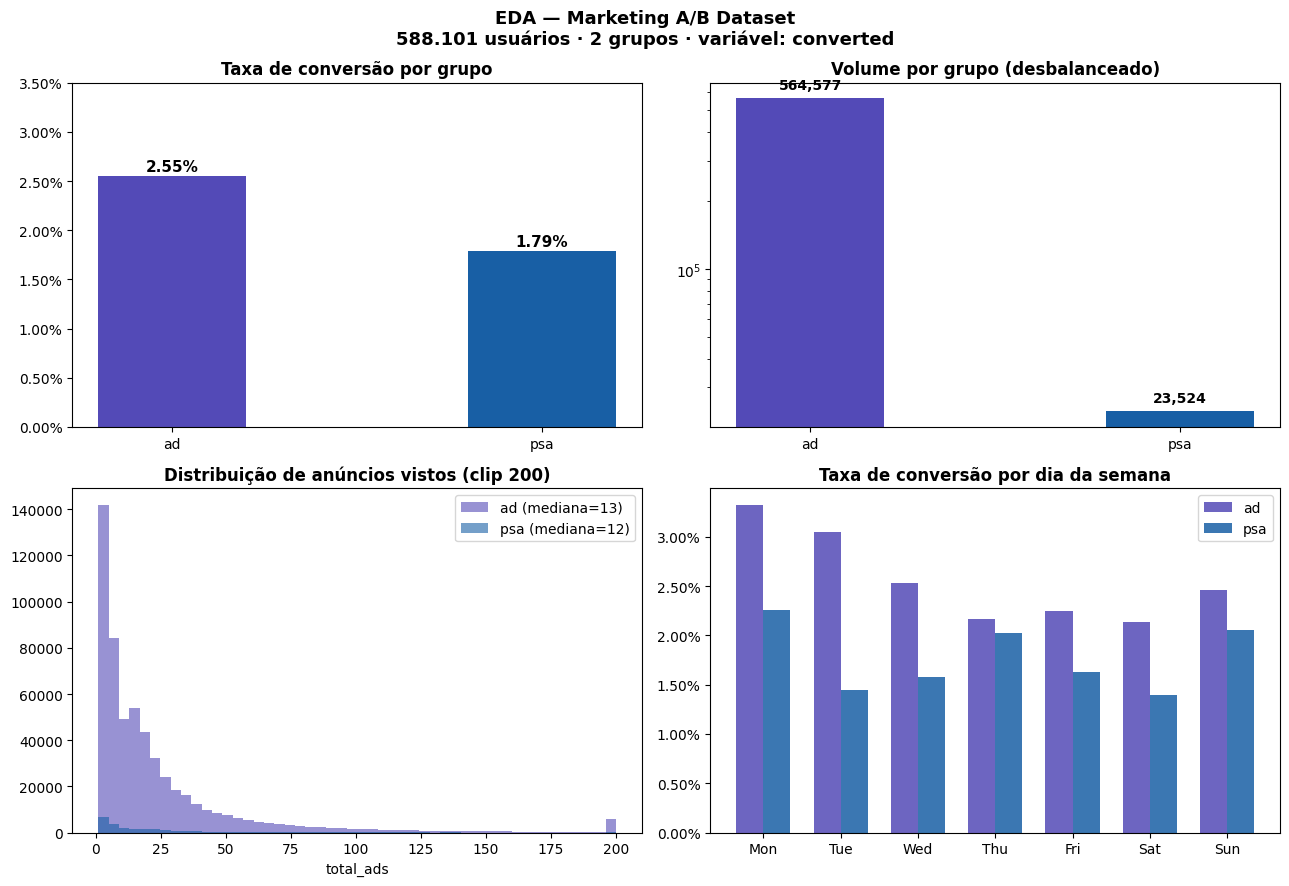

✓ EDA salvo em reports/eda_fase1.png


In [36]:
# ── CÉLULA 12: EDA ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('EDA — Marketing A/B Dataset\n588.101 usuários · 2 grupos · variável: converted',
             fontsize=13, fontweight='bold')

cores = {'ad': '#534AB7', 'psa': '#185FA5'}

# ── Plot 1: taxa de conversão por grupo ─────────────────────────────────────
grupos = ['ad', 'psa']
taxas  = [0.0255, 0.0179]
bars   = axes[0,0].bar(grupos, taxas, color=[cores['ad'], cores['psa']], width=0.4)
axes[0,0].set_title('Taxa de conversão por grupo', fontweight='bold')
axes[0,0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=2))
axes[0,0].set_ylim(0, 0.035)
for bar, v in zip(bars, taxas):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, v + 0.0005,
                   f'{v:.2%}', ha='center', fontsize=11, fontweight='bold')

# ── Plot 2: volume por grupo (escala log) ────────────────────────────────────
volumes = [564577, 23524]
bars2   = axes[0,1].bar(grupos, volumes, color=[cores['ad'], cores['psa']], width=0.4)
axes[0,1].set_title('Volume por grupo (desbalanceado)', fontweight='bold')
axes[0,1].set_yscale('log')
for bar, v in zip(bars2, volumes):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, v * 1.1,
                   f'{v:,.0f}', ha='center', fontsize=10, fontweight='bold')

# ── Plot 3: distribuição de total_ads por grupo ──────────────────────────────
for grp, cor in cores.items():
    subset = df[df['test_group'] == grp]['total_ads']
    axes[1,0].hist(subset.clip(upper=200), bins=50, alpha=0.6,
                   color=cor, label=f'{grp} (mediana={subset.median():.0f})')
axes[1,0].set_title('Distribuição de anúncios vistos (clip 200)', fontweight='bold')
axes[1,0].set_xlabel('total_ads')
axes[1,0].legend()

# ── Plot 4: taxa de conversão por dia da semana ──────────────────────────────
ordem_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
conv_dia = df.groupby(['most_ads_day','test_group'])['converted'].mean().unstack()
conv_dia = conv_dia.reindex(ordem_dias)
x = np.arange(len(ordem_dias))
w = 0.35
axes[1,1].bar(x - w/2, conv_dia['ad'],  w, color=cores['ad'],  label='ad',  alpha=0.85)
axes[1,1].bar(x + w/2, conv_dia['psa'], w, color=cores['psa'], label='psa', alpha=0.85)
axes[1,1].set_title('Taxa de conversão por dia da semana', fontweight='bold')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels([d[:3] for d in ordem_dias])
axes[1,1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=2))
axes[1,1].legend()

plt.tight_layout()
plt.savefig(f'{BASE}/reports/eda_fase1.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ EDA salvo em reports/eda_fase1.png")

In [37]:
# ── CÉLULA 13: salvar notebook atualizado ───────────────────────────────────
import shutil, glob

for nb in glob.glob('/content/*.ipynb'):
    shutil.copy(nb, f'{BASE}/notebooks/')

print("✓ Notebook atualizado no Drive")
print(f"\nResumo final da Fase 1:")
print(f"  data/raw/   → marketing_AB_raw.csv")
print(f"  data/clean/ → ab_test_clean.parquet")
print(f"  reports/    → eda_fase1.png, teorema_bayes_visual.png,")
print(f"                conjugate_beta_binomial.png, hdi_vs_ic.png")
print(f"  notebooks/  → Setup_notebook01.ipynb")

✓ Notebook atualizado no Drive

Resumo final da Fase 1:
  data/raw/   → marketing_AB_raw.csv
  data/clean/ → ab_test_clean.parquet
  reports/    → eda_fase1.png, teorema_bayes_visual.png,
                conjugate_beta_binomial.png, hdi_vs_ic.png
  notebooks/  → Setup_notebook01.ipynb
